In [1]:
import pandas as pd
import seaborn as sns
import treedata
import pickle
import matplotlib.pyplot as plt

import numpy as np
from tqdm.notebook import tqdm

In [2]:
# umap_coords = pd.read_csv('/home/gokulg/orcd/scratch/lt/data/final_umap.csv', index_col=0)
cell_types = pd.read_csv('/home/gokulg/orcd/scratch/lt/data/final_subtype.csv', index_col=0)
type_info = pd.read_csv('/home/gokulg/orcd/scratch/lt/data/final_type_info.csv', index_col=0)
name_to_subtype = {name: cell_types.loc[name, 'cell_subtype'] for name in cell_types.index}
subtype_to_lineage = {subtype: type_info.loc[subtype, 'lineage'] for subtype in type_info.index}
type_info.head(3)

,cell_type,cluster,lineage,germ_layer,type_color,id,subtype_id,subtype_color
cell_subtype,,,,,,,,
rostral ectoderm,rostral ectoderm,early,ectoderm,ectoderm,#a05837,1,1,#a05837
amniotic ectoderm,amniotic ectoderm,extraembryonic and pgc,extraembryonic ectoderm,ectoderm,#c0b9b2,2,2,#c0b9b2
extraembryonic ectoderm,extraembryonic ectoderm,extraembryonic and pgc,extraembryonic ectoderm,ectoderm,#bc23ff,3,3,#bc23ff


In [3]:
import pickle
import glob

node_mmd = {}
for path in sorted(glob.glob("commitment/per_tree/node_mmd_0*.pkl")):
    with open(path, "rb") as f:
        node_mmd.update(pickle.load(f))

In [ ]:
# node_mmd = pickle.load(open("commitment/per_tree/node_mmd_000.pkl", "rb"))

In [5]:
df = pd.DataFrame(node_mmd).T


In [6]:
len(node_mmd)

263606

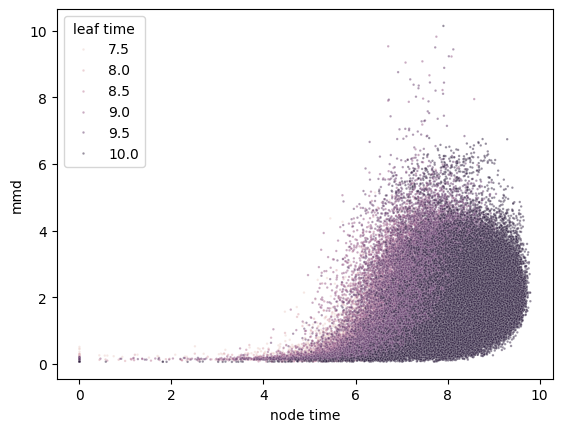

In [10]:
# sns.scatterplot(data=df, x="node time", y="perm_mean", hue='leaf time', s=3, alpha=0.5)
sns.scatterplot(data=df, x="node time", y="mmd", hue='leaf time', s=3, alpha=0.5)
plt.show()